In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [14]:
gt = np.load('label_results/dataset_re_bs128_sl96_dm16_df16_ln3_k2_embtimeF_ar20.0_lr1e-05_pt20_te50_bn1_0/gt.npy')
# pred = np.load('label_results/dataset_re_bs128_sl96_dm16_df16_ln3_k2_embtimeF_ar20.0_lr1e-05_pt20_te50_bn1_0/pred.npy')
test_energy = np.load('label_results/dataset_re_bs128_sl96_dm16_df16_ln3_k2_embtimeF_ar20.0_lr1e-05_pt20_te50_bn1_0/test_energy.npy')
gt.shape

(430080,)

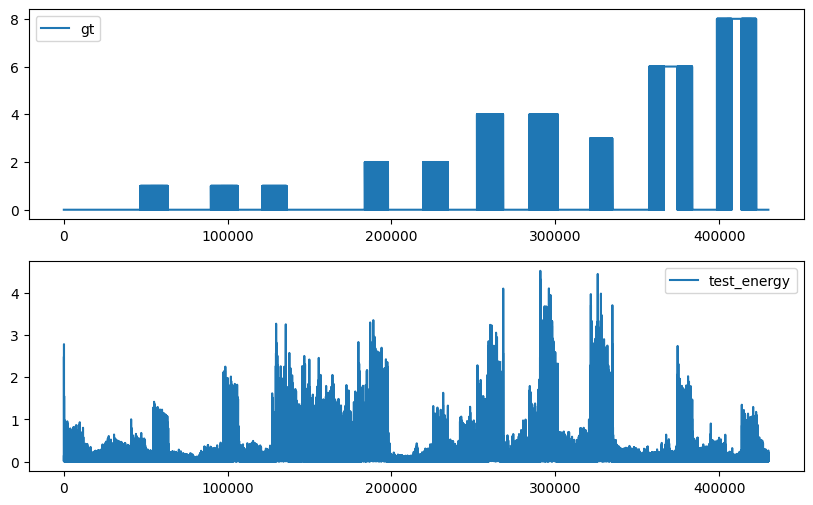

In [15]:
# 绘制gt和test_energy
# 分别绘制两个子图，gt采用折线图，test_energy采用折线图
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(gt, label='gt')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(test_energy, label='test_energy')
plt.legend()
plt.show()

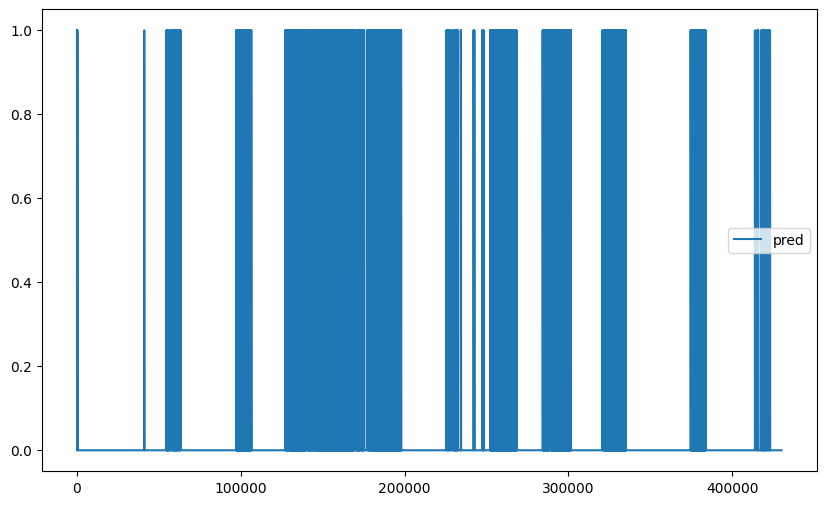

In [16]:
# 设置阈值将test_energy转换为pred
threshold = 1
pred = np.zeros_like(test_energy)
pred[test_energy > threshold] = 1
pred[test_energy <= threshold] = 0
# 绘制pred
plt.figure(figsize=(10, 6))
plt.plot(pred, label='pred')
plt.legend()
plt.show()

In [17]:
# 提取数据集
test_data = np.load('label_results/dataset_re_bs128_sl96_dm16_df16_ln3_k2_embtimeF_ar20.0_lr1e-05_pt20_te50_bn1_0/test_data.npy')
# 将test_data沿第0维拼接
test_data = np.concatenate(test_data, axis=0)
test_data.shape

(430080, 18)

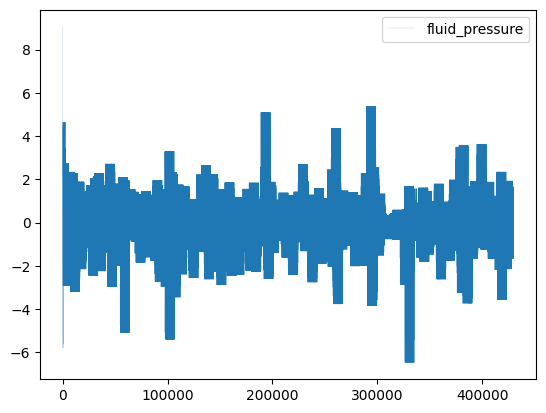

(430080,)


In [24]:
# 绘制test_data第0维折线图,线宽为1
plt.plot(test_data[:, 1], linewidth=0.1, label='fluid_pressure')
plt.legend()
plt.show()
print(test_data[:, 1].shape)

In [19]:
# 保存gt,test_energy,pred,test_data为csv文件
# np.savetxt('gt.csv', gt, delimiter=',')
# np.savetxt('test_energy.csv', test_energy, delimiter=',')
# np.savetxt('pred.csv', pred, delimiter=',')
# np.savetxt('test_data.csv', test_data, delimiter=',')

In [20]:
x_out = np.load('label_results/dataset_re_bs128_sl96_dm16_df16_ln3_k2_embtimeF_ar20.0_lr1e-05_pt20_te50_bn1_0/re/layer_outputs.npy',allow_pickle=True)

In [21]:
# 检查数据的形状和类型  
print(type(x_out))         # x_out 类型是什么  
print(len(x_out))          # x_out 的长度（数组中有多少个对象）  
print(type(x_out[0]))      # 第一个对象的类型  
# print(x_out[0])            # 查看第一个对象的内容


<class 'numpy.ndarray'>
4620
<class 'dict'>


In [22]:
# 计算 input + seasonality + trend   
results = []  # 保存结果列表  
for idx, item in enumerate(x_out):  # 遍历每个字典  
    # 确保当前item中有三个关键字  
    if 'input' in item and 'seasonality' in item and 'trend' in item:  
        # 读取 input, seasonality, trend  
        input_data = np.array(item['input'])           # 转为 NumPy 数组  
        seasonality = np.array(item['seasonality'])    # 转为 NumPy 数组  
        trend = np.array(item['trend'])               # 转为 NumPy 数组  

        # 按元素加和  
        result = input_data + seasonality + trend  
        results.append(result)  
        # print(f"第 {idx + 1} 个计算完成结果，形状：{result.shape}")  # 查看当前结果形状  

    else:  
        print(f"第 {idx + 1} 个对象没有正确的键: {item.keys()}")  

# 转化为数组（如果所有结果大小一致）  
results_array = np.array(results)  
print("所有加和结果的形状：", results_array.shape)  # 查看最终形状  

所有加和结果的形状： (4620, 128, 96, 18)
